# How to add synaptic delays

**Task.** Give a projection an axonal/synaptic transmission delay, so
presynaptic spikes arrive at the target some milliseconds later.

**Audience.** Simulation. Assumes :doc:`../tutorials/02-synapse-and-projection`.

A projection reads its presynaptic signal through a **prefetch**. To delay that
signal, attach `.delay.at(<delay>)` to the prefetched state. Because the
built-in neurons expose their membrane potential `V` (not a stored spike), we
prefetch `V`, delay it, and re-derive the delayed spikes with `get_spike`. This
is the same idiom the gallery's large networks use.

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import matplotlib.pyplot as plt

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## A delayed projection

The projection is built **once** with the delayed prefetch as its spike
generator, then called with no arguments inside `update()` (it pulls the delayed
signal itself).

In [2]:
class DelayedNet(brainstate.nn.Module):
    def __init__(self, delay, n_pre=100, n_post=100):
        super().__init__()
        self.pre = brainpy.state.LIFRef(
            n_pre, tau=20. * u.ms, tau_ref=5. * u.ms,
            V_rest=-60. * u.mV, V_th=-50. * u.mV, V_reset=-60. * u.mV)
        self.post = brainpy.state.LIFRef(
            n_post, tau=20. * u.ms, tau_ref=5. * u.ms,
            V_rest=-60. * u.mV, V_th=-50. * u.mV, V_reset=-60. * u.mV)
        self.proj = brainpy.state.AlignPostProj(
            # delay the presynaptic V, then decode spikes from the delayed V
            self.pre.prefetch('V').delay.at(delay),
            lambda v: self.pre.get_spike(v) != 0.,
            comm=brainstate.nn.EventFixedProb(
                n_pre, n_post, conn_num=0.1, conn_weight=0.5 * u.mS),
            syn=brainpy.state.Expon.desc(n_post, tau=5. * u.ms),
            out=brainpy.state.COBA.desc(E=0. * u.mV),
            post=self.post)

    def update(self, t, drive):
        with brainstate.environ.context(t=t):
            self.proj()                       # pulls the delayed presynaptic spikes
            self.pre(drive)
            self.post(0. * u.mA)
            return self.pre.get_spike(), self.post.get_spike()

## Compare two delays

Run the network with a short delay and a long delay and look at when
postsynaptic activity appears relative to presynaptic activity.

In [3]:
def run(delay, t_stop=150. * u.ms):
    with brainstate.environ.context(dt=0.1 * u.ms):
        net = DelayedNet(delay)
        brainstate.nn.init_all_states(net)
        times = u.math.arange(0. * u.ms, t_stop, brainstate.environ.get_dt())
        pre_spk, post_spk = brainstate.transform.for_loop(
            lambda t: net.update(t, 30. * u.mA), times)
    return times, pre_spk, post_spk


with brainstate.environ.context(dt=0.1 * u.ms):
    res = {'1 ms delay': run(1. * u.ms), '10 ms delay': run(10. * u.ms)}

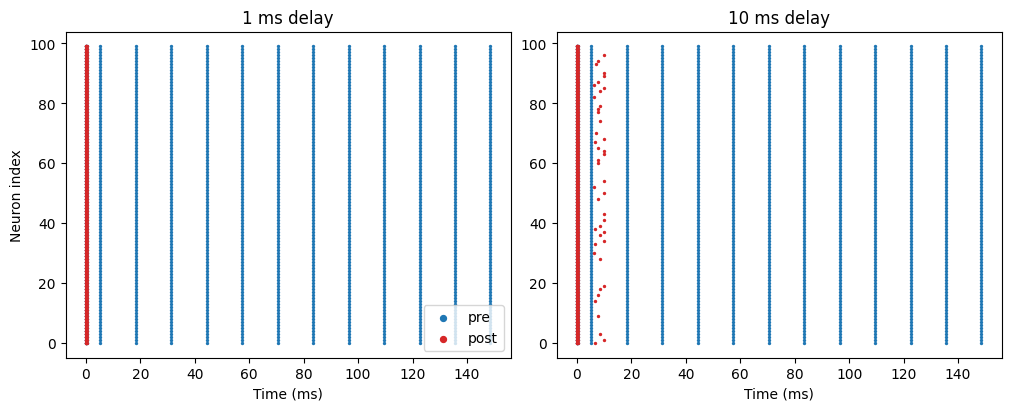

In [4]:
fig, gs = braintools.visualize.get_figure(1, 2, 4.0, 5.0)
for k, (title, (times, pre_spk, post_spk)) in enumerate(res.items()):
    ax = fig.add_subplot(gs[0, k])
    ti, ni = u.math.where(pre_spk)
    ax.scatter(times[ti].to_decimal(u.ms), ni, s=2, color='C0', label='pre')
    ti, ni = u.math.where(post_spk)
    ax.scatter(times[ti].to_decimal(u.ms), ni, s=2, color='C3', label='post')
    ax.set_title(title); ax.set_xlabel('Time (ms)')
    if k == 0:
        ax.set_ylabel('Neuron index'); ax.legend(loc='lower right', markerscale=3)
plt.show()

## See also

- :doc:`../tutorials/02-synapse-and-projection` — the undelayed baseline.
- :doc:`/concepts/alignpre-alignpost` — prefetch and projection routing.
- :doc:`sim-reproduce-a-paper` — delays in a published network.